In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from scipy.stats import skew, kurtosis, mode

np.random.seed(42)
sns.set_style("whitegrid")

In [5]:

n = 500


A = np.random.normal(loc=50, scale=10, size=n)

B = np.random.exponential(scale=1, size=n)
B = (B / B.max()) * 100 

C1 = np.random.normal(loc=30, scale=5, size=n//2)
C2 = np.random.normal(loc=70, scale=5, size=n//2)
C = np.concatenate([C1, C2])

datasets = {"Dataset A": A, "Dataset B": B, "Dataset C": C}

In [6]:
def summarize(data):

    mean = np.mean(data)
    median = np.median(data)
    mode_val = mode(data, keepdims=False).mode

    std = np.std(data, ddof=1)
    var = np.var(data, ddof=1)

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    sk = skew(data)
    kurt = kurtosis(data)

    return [mean, median, mode_val, std, var, iqr, sk, kurt]


columns = [
    "Mean","Median","Mode",
    "Std Dev","Variance","IQR",
    "Skewness","Kurtosis"
]

summary_table = pd.DataFrame(
    [summarize(datasets[k]) for k in datasets],
    index=datasets.keys(),
    columns=columns
).round(2)


Some statistics such as mean and median may appear somewhat similar across datasets because they represent central tendency. However, skewness and kurtosis clearly reveal differences in distribution shape. For example, the right-skewed dataset has high positive skewness, while the bimodal dataset may show kurtosis differences due to its two peaks.

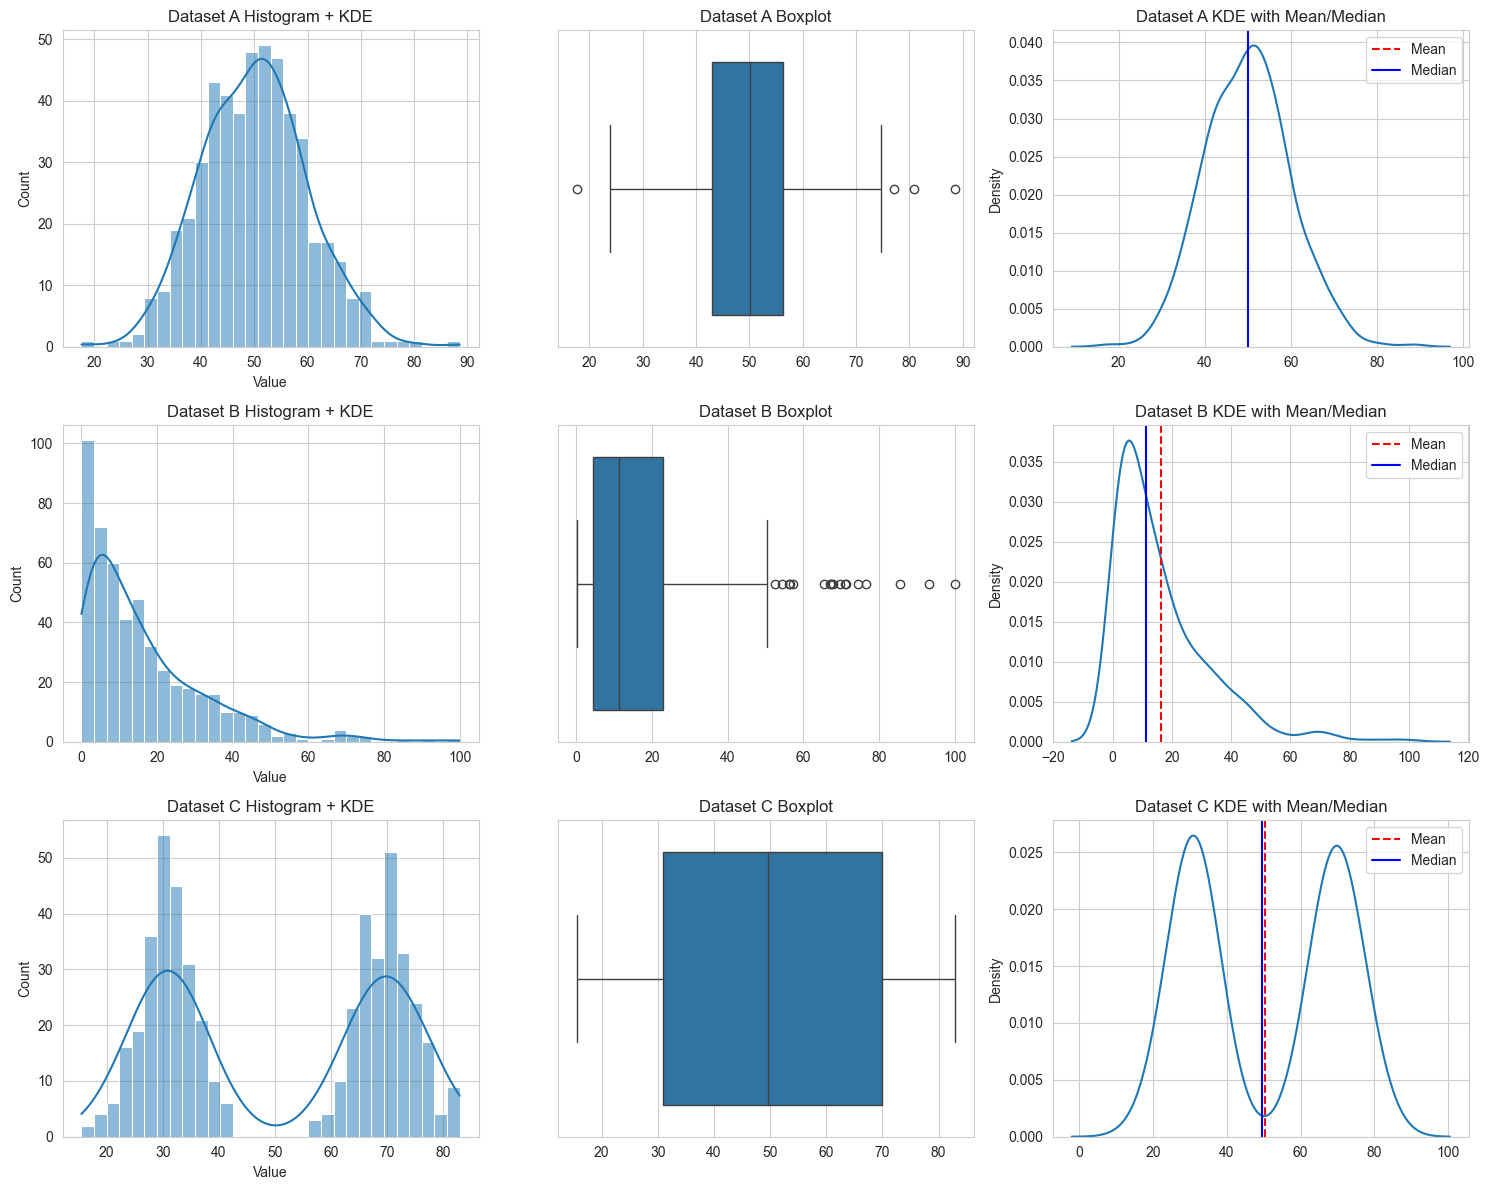

In [7]:
fig, axes = plt.subplots(3,3, figsize=(15,12))

for row, (name, data) in enumerate(datasets.items()):

    sns.histplot(data, bins=30, kde=True, ax=axes[row,0])
    axes[row,0].set_title(f"{name} Histogram + KDE")
    axes[row,0].set_xlabel("Value")

    sns.boxplot(x=data, ax=axes[row,1])
    axes[row,1].set_title(f"{name} Boxplot")

    sns.kdeplot(data, ax=axes[row,2])

    mean_val = np.mean(data)
    median_val = np.median(data)

    axes[row,2].axvline(mean_val, color="red", linestyle="--", label="Mean")
    axes[row,2].axvline(median_val, color="blue", linestyle="-", label="Median")

    axes[row,2].set_title(f"{name} KDE with Mean/Median")
    axes[row,2].legend()

plt.tight_layout()
plt.show()

The largest divergence between mean and median occurs in Dataset B (right-skewed). The histogram and KDE show a long tail extending to the right, which pulls the mean toward larger values while the median stays closer to the central mass of the data.

In [8]:
A_modified = A.copy()

largest_indices = np.argsort(A_modified)[-5:]
A_modified[largest_indices] = A_modified[largest_indices] * 10

datasets_outlier = {
    "Original A": A,
    "Modified A": A_modified
}

summary_outlier = pd.DataFrame(
    [summarize(datasets_outlier[k]) for k in datasets_outlier],
    index=datasets_outlier.keys(),
    columns=columns
).round(2)


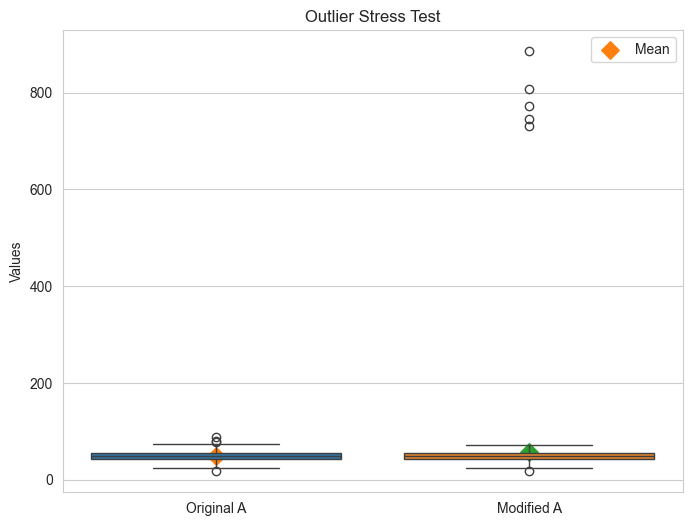

In [9]:
plt.figure(figsize=(8,6))

sns.boxplot(data=[A, A_modified])

plt.xticks([0,1],["Original A","Modified A"])
plt.scatter(0, np.mean(A), marker="D", s=80, label="Mean")
plt.scatter(1, np.mean(A_modified), marker="D", s=80)

plt.title("Outlier Stress Test")
plt.ylabel("Values")
plt.legend()

plt.show()

The mean, variance, and standard deviation changed the most after introducing extreme outliers. These statistics are highly sensitive to extreme values.

The median and IQR were much more robust, showing little change because they depend on the middle portion of the data rather than extreme values.

If reporting a typical value for the modified dataset, the median would be preferable because it is resistant to outliers and better represents the central tendency when extreme values are present.